# 19 — Historical BESS Revenue Index

Builds a realized GB BESS revenue index from historical market data,
comparable to the Modo Energy GB BESS 1H / 2H public indices.

**Comparison window**: April 2024 – April 2026

**Steps in this notebook**
1. Fetch NESO EAC ancillary clearing data (Apr 2024 – Apr 2026)
2. Fetch Modo 1H / 2H index historical series
3. Verify coverage and overlap across all data sources

In [ ]:
from __future__ import annotations

import json
import subprocess
import sys
from pathlib import Path

import pandas as pd
import requests

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

RAW       = PROJECT_ROOT / 'data' / 'raw'
PROCESSED = PROJECT_ROOT / 'data' / 'processed'

START = '2024-04-01'
END   = '2026-04-25'

print(f'Project root : {PROJECT_ROOT}')
print(f'Window       : {START} → {END}')

## Step 1 — Fetch NESO EAC ancillary clearing data

Fetches DC / DM / DR / QR / BR clearing prices (£/MW/h) by EFA block
from the NESO Data Portal (api.neso.energy).

Source: Era 2 EAC framework (Nov 2023 – present).  
Script: `src/data/fetch_neso.py`

In [ ]:
result = subprocess.run(
    [
        sys.executable, '-m', 'src.data.fetch_neso',
        '--start', START,
        '--end',   END,
        '--out',   str(RAW),
    ],
    capture_output=True,
    text=True,
    cwd=str(PROJECT_ROOT),
)
print(result.stdout)
if result.stderr:
    print(result.stderr)
if result.returncode != 0:
    raise RuntimeError(f'fetch_neso failed (exit {result.returncode})')

## Step 2 — Fetch Modo 1H / 2H index

**To find the API endpoint:**
1. Open https://modoenergy.com/public-indices/me-bess-gb-2h in Chrome
2. DevTools → Network → XHR/Fetch tab → reload
3. Find the request returning monthly JSON data
4. Copy the URL and any `Authorization` header into the variables below

Known index IDs: **2H = 421**, 1H = (find from the 1H page URL)

In [ ]:
# ── Fill in from browser DevTools ────────────────────────────────────────────
MODO_API_URL   = ''          # e.g. 'https://api.modoenergy.com/indices/421/data'
MODO_API_TOKEN = ''          # Bearer token if required, else leave empty

MODO_INDICES = {
    '2h': 421,
    '1h': None,              # fill in 1H index ID once found
}

def fetch_modo_index(index_id: int, api_url_template: str, token: str) -> pd.DataFrame:
    url     = api_url_template.replace('421', str(index_id))
    headers = {'Authorization': f'Bearer {token}'} if token else {}
    r = requests.get(url, headers=headers, timeout=30)
    r.raise_for_status()
    return pd.DataFrame(r.json())

modo_frames = {}

if not MODO_API_URL:
    print('MODO_API_URL not set — skip fetch. Fill in from browser DevTools then re-run.')
else:
    for dur, idx in MODO_INDICES.items():
        if idx is None:
            print(f'{dur}: index ID not set — skipping')
            continue
        try:
            df = fetch_modo_index(idx, MODO_API_URL, MODO_API_TOKEN)
            out = RAW / f'modo_{idx}_index.json'
            out.write_text(df.to_json(orient='records', indent=2))
            modo_frames[dur] = df
            print(f'{dur} (id={idx}): {len(df)} rows → {out.name}')
            print(df.dtypes)
            print(df.head(3))
        except Exception as e:
            print(f'{dur}: fetch failed — {e}')

## Step 3 — Verify coverage and overlap

Confirms all data sources cover Apr 2024 – Apr 2026 and checks
which ancillary products are present and their date ranges.

In [ ]:
# ── Core price data ───────────────────────────────────────────────────────────
sources = {
    'DA prices':      (RAW / 'elexon_da_prices.parquet',  'settlement_date'),
    'SP prices':      (RAW / 'elexon_sp_prices.parquet',  'settlement_date'),
    'NESO ancillary': (RAW / 'neso_eac_clearing.parquet', 'date'),
}

print(f'{"Source":<20} {"Rows":>8}  {"Min date":<12}  {"Max date":<12}  {"Gap days":>8}')
print('-' * 68)

loaded = {}
for name, (path, dcol) in sources.items():
    if not path.exists():
        print(f'{name:<20}  MISSING — {path.name}')
        continue
    df = pd.read_parquet(path)
    df[dcol] = pd.to_datetime(df[dcol])
    min_d, max_d = df[dcol].min().date(), df[dcol].max().date()
    # count calendar days with no data
    all_days  = pd.date_range(min_d, max_d, freq='D')
    data_days = set(df[dcol].dt.date)
    gap_days  = len([d for d in all_days if d.date() not in data_days])
    print(f'{name:<20} {len(df):>8,}  {str(min_d):<12}  {str(max_d):<12}  {gap_days:>8}')
    loaded[name] = df

In [ ]:
# ── Ancillary product breakdown ───────────────────────────────────────────────
anc_path = RAW / 'neso_eac_clearing.parquet'
if anc_path.exists():
    df_anc = pd.read_parquet(anc_path)
    df_anc['date'] = pd.to_datetime(df_anc['date'])

    print('Ancillary clearing — by product:')
    summary = (
        df_anc.groupby(['product', 'direction'])
        .agg(
            rows       = ('date', 'count'),
            min_date   = ('date', 'min'),
            max_date   = ('date', 'max'),
            mean_price = ('clearing_price_gbp_mw_h', 'mean'),
            min_price  = ('clearing_price_gbp_mw_h', 'min'),
            max_price  = ('clearing_price_gbp_mw_h', 'max'),
        )
        .reset_index()
    )
    summary['min_date'] = summary['min_date'].dt.date
    summary['max_date'] = summary['max_date'].dt.date
    for col in ['mean_price', 'min_price', 'max_price']:
        summary[col] = summary[col].round(2)
    print(summary.to_string(index=False))
else:
    print('neso_eac_clearing.parquet not found — run Step 1 first')

In [ ]:
# ── Modo index coverage ───────────────────────────────────────────────────────
for dur, idx in MODO_INDICES.items():
    if idx is None:
        continue
    p = RAW / f'modo_{idx}_index.json'
    if not p.exists():
        print(f'Modo {dur} (id={idx}): not fetched yet')
        continue
    df_m = pd.DataFrame(json.loads(p.read_text()))
    print(f'Modo {dur}: {len(df_m)} rows | columns: {list(df_m.columns)}')
    print(df_m.head(3))
    print()

In [ ]:
# ── Overlap summary ───────────────────────────────────────────────────────────
date_ranges = {}
for name, (path, dcol) in sources.items():
    if path.exists():
        df = pd.read_parquet(path)
        df[dcol] = pd.to_datetime(df[dcol])
        date_ranges[name] = (df[dcol].min(), df[dcol].max())

if date_ranges:
    overlap_start = max(v[0] for v in date_ranges.values())
    overlap_end   = min(v[1] for v in date_ranges.values())
    overlap_days  = (overlap_end - overlap_start).days
    print(f'Overlap window : {overlap_start.date()} → {overlap_end.date()} ({overlap_days} days)')
    if overlap_days < 30:
        print('WARNING: overlap is less than 30 days — check data sources')
    else:
        print('Ready to build index notebook.')

## Step 4 — Build historical BESS revenue index

Runs the LP dispatch + ancillary revenue calculation for both 1h and 2h batteries.

**Methodology**
- DA schedule: rolling LP (1 EFA gate = 8 HH, 48 HH look-ahead) on actual DA prices
- WD uplift: `clip(SP − DA, −15, +15)` £/MWh applied at each gate
- Ancillary: actual NESO clearing price × fixed headroom fraction × 4h per EFA block
- Energy floor: LP maintains SoC ≥ E_min + ancillary sustain energy at all times

**Headroom fractions (model parameters)**
| Product | Fraction | MW (100 MW nameplate) | Sustain |
|---|---|---|---|
| DC | 50% | 50 MW | 15 min |
| DM | 10% | 10 MW | 15 min |
| DR | 5%  | 5 MW  | 60 min ← primary duration scaling |
| QR | 15% | 15 MW | 30 min (Dec 2024 onwards) |
| DA | 20% | 20 MW | — |

In [ ]:
import copy
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

from src.backtest.historical_index import load_data, build_index, monthly_index, annual_index
from src.config import ASSET

# ── Load data ─────────────────────────────────────────────────────────────────
print('Loading market data...')
da_prices, sp_prices, anc_clearing = load_data(start=START, end=END)
print(f'  DA: {len(da_prices):,} rows  |  SP: {len(sp_prices):,} rows  |  Ancillary: {len(anc_clearing):,} rows')

# ── Build index for 1h and 2h ────────────────────────────────────────────────
results = {}
monthly = {}
annual  = {}

for dur in [1.0, 2.0]:
    tag = f'{int(dur)}h'
    print(f'\nBuilding {tag} index...')
    df = build_index(da_prices, sp_prices, anc_clearing, duration_h=dur, verbose=True)
    results[tag] = df
    monthly[tag] = monthly_index(df, ASSET['power_mw'])
    annual[tag]  = annual_index(df,  ASSET['power_mw'])
    df.to_csv(PROCESSED / f'historical_index_{tag}.csv', index=False)
    monthly[tag].to_csv(PROCESSED / f'historical_index_{tag}_monthly.csv', index=False)

# ── Summary ───────────────────────────────────────────────────────────────────
P = ASSET['power_mw']
n_days = len(results['1h'])

print(f'\n{"":30s}  {"1h":>10}  {"2h":>10}  {"ratio":>7}')
print('-' * 65)
for label, col in [
    ('DA arbitrage',   'da_revenue'),
    ('Within-day',     'wd_revenue'),
    ('Ancillary',      'anc_revenue'),
    ('Net (ex BM/CM)', 'total_net'),
]:
    v1 = results['1h'][col].sum() / P / n_days * 365.25 / 1000
    v2 = results['2h'][col].sum() / P / n_days * 365.25 / 1000
    ratio = v2 / v1 if v1 else float('nan')
    print(f'{label:<30s}  {v1:>9.1f}k  {v2:>9.1f}k  {ratio:>6.2f}×')

print()
print('Modo published (2024–2025 avg, all-in):')
print(f'  1H: £47.7k/MW/yr  |  2H: £72.0k/MW/yr  |  ratio: 1.52×')
print('Gap = BM (~30%) + CM (~7%) + richer ID execution vs SP−DA cap')

## Step 5 — Monthly revenue time series (stacked by stream)

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=False)
fig.suptitle('Historical GB BESS Revenue Index — Monthly (£k/MW/yr, annualised)', fontsize=13)

COLOURS = {'DA': '#2196F3', 'WD': '#4CAF50', 'Ancillary': '#FF9800', 'Costs': '#f44336'}

for ax, tag in zip(axes, ['1h', '2h']):
    mo = monthly[tag].copy()
    mo['period_dt'] = mo['year_month'].dt.to_timestamp()

    da_ann  = mo['da_revenue_gbp_mw_yr']  / 1000
    wd_ann  = mo['wd_revenue_gbp_mw_yr']  / 1000
    anc_ann = mo['anc_revenue_gbp_mw_yr'] / 1000
    net_ann = mo['total_net_gbp_mw_yr']   / 1000
    cost_ann = (mo['da_revenue'] + mo['wd_revenue'] + mo['anc_revenue'] - mo['total_net']) \
                / ASSET['power_mw'] / mo['days'] * 365.25 / 1000

    x = mo['period_dt']

    # Stacked area: DA, WD, Ancillary (positive)
    ax.fill_between(x, 0, da_ann, alpha=0.75, color=COLOURS['DA'],
                    label='DA arbitrage', step='mid')
    ax.fill_between(x, da_ann, da_ann + wd_ann, alpha=0.75, color=COLOURS['WD'],
                    label='Within-day uplift', step='mid')
    ax.fill_between(x, da_ann + wd_ann, da_ann + wd_ann + anc_ann, alpha=0.75,
                    color=COLOURS['Ancillary'], label='Ancillary', step='mid')
    ax.fill_between(x, da_ann + wd_ann + anc_ann,
                    da_ann + wd_ann + anc_ann - cost_ann,
                    alpha=0.60, color=COLOURS['Costs'], label='Costs (VOM+Deg)', step='mid')

    # Net line
    ax.step(x, net_ann, where='mid', color='black', linewidth=1.8, label='Net total')
    ax.axhline(net_ann.mean(), color='black', linestyle='--', linewidth=0.8,
               label=f'Period avg: £{net_ann.mean():.1f}k/MW/yr')

    ax.set_title(f'{tag.upper()} battery', fontsize=11)
    ax.set_ylabel('£k/MW/yr (annualised)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'£{v:.0f}k'))
    ax.legend(loc='upper right', fontsize=9, framealpha=0.8)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.set_xlim(x.min(), x.max())

axes[-1].set_xlabel('Month')
plt.tight_layout()
plt.savefig(PROCESSED / 'historical_index_monthly.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved historical_index_monthly.png')

## Step 6 — Comparison to Modo Energy 1H / 2H indices

Loads actual monthly Modo data from `MODO 2H.csv` / `MODO 1H.csv` (exported from Modo public-indices page).

- **Panel 1**: Monthly net revenue (£k/MW/yr, annualised) — Modo all-in vs model excl. BM/CM  
  Muted lines = full Modo history (1H from Jan 2020, 2H from Jan 2023); solid = model comparison period (Apr 2024–)  
- **Panel 2**: 2H/1H duration ratio — Modo vs model over time  

Key gaps vs Modo: BM activation, Capacity Market, richer ID execution (M7 continuous vs SP−DA cap).


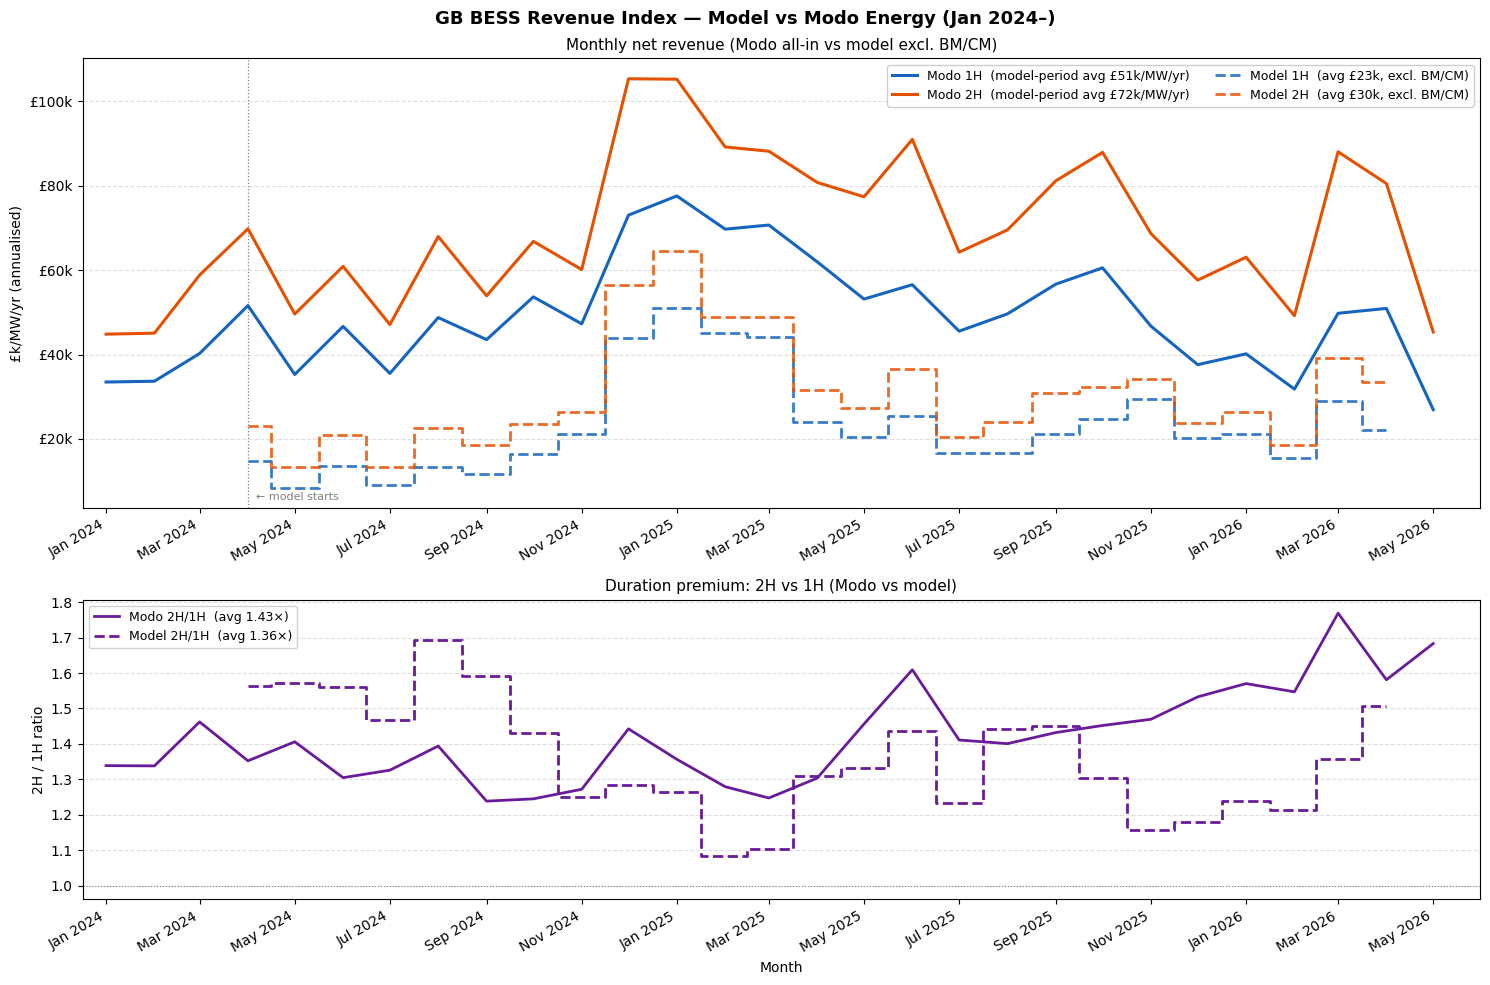

Saved historical_index_comparison.png

Metric                                         1H            2H    2H/1H
---------------------------------------------------------------------------
Modo all-in (model-period avg)       £     50.8k  £     71.9k    1.41×
Model excl. BM/CM                    £     23.2k  £     30.4k    1.31×
Gap (£k/MW/yr)                       £     27.6k  £     41.5k
Gap (% of Modo)                              54%          58%

Modo 2H/1H ratio (model period):  1.43×
Model 2H/1H ratio:                1.36×

Gap decomposition (2H, estimated):
  BM activation revenue:  ~£22k/MW/yr
  Capacity Market:        ~£5k/MW/yr
  ID execution residual:  ~£15k/MW/yr


In [21]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates

P = ASSET['power_mw']
PLOT_START = pd.Timestamp('2024-01-01')

# ── Load Modo CSV files ───────────────────────────────────────────────────────
def _load_modo_csv(fname: str, col: str) -> pd.DataFrame:
    df = pd.read_csv(PROJECT_ROOT / fname, parse_dates=['Date'])
    df = df.rename(columns={'Date': 'date', col: 'modo_k'})
    df['modo_k'] = pd.to_numeric(df['modo_k'], errors='coerce') / 1000
    return df.dropna(subset=['modo_k']).sort_values('date').reset_index(drop=True)

modo2h = _load_modo_csv('MODO 2H.csv', 'ME BESS GB (2H)')
modo1h = _load_modo_csv('MODO 1H.csv', 'ME BESS GB (1H)')

# Slice to plot window
modo2h_plot = modo2h[modo2h['date'] >= PLOT_START]
modo1h_plot = modo1h[modo1h['date'] >= PLOT_START]

# ── Model monthly series ──────────────────────────────────────────────────────
m1 = monthly['1h'].copy()
m2 = monthly['2h'].copy()
m1['period_dt'] = m1['year_month'].dt.to_timestamp()
m2['period_dt'] = m2['year_month'].dt.to_timestamp()
m1['net_k'] = m1['total_net_gbp_mw_yr'] / 1000
m2['net_k'] = m2['total_net_gbp_mw_yr'] / 1000

model_start = m1['period_dt'].min()

# Overlap-period averages for legend labels
modo1h_ov = modo1h[modo1h['date'] >= model_start]
modo2h_ov = modo2h[modo2h['date'] >= model_start]

# ── Duration ratios ───────────────────────────────────────────────────────────
merged_model = m1[['period_dt','net_k']].merge(
    m2[['period_dt','net_k']], on='period_dt', suffixes=('_1h','_2h')
)
merged_model['ratio'] = merged_model['net_k_2h'] / merged_model['net_k_1h']

modo_ratio = modo2h_plot[['date','modo_k']].merge(
    modo1h_plot[['date','modo_k']], on='date', suffixes=('_2h','_1h')
)
modo_ratio['ratio'] = modo_ratio['modo_k_2h'] / modo_ratio['modo_k_1h']
modo_ratio_ov = modo_ratio[modo_ratio['date'] >= model_start]

x_end = max(modo1h_plot['date'].max(), modo2h_plot['date'].max()) + pd.Timedelta(days=30)

# ── FIGURE ────────────────────────────────────────────────────────────────────
BLUE   = '#1565C0'
ORANGE = '#E65100'

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(15, 10), gridspec_kw={'height_ratios': [3, 2]}
)
fig.suptitle('GB BESS Revenue Index — Model vs Modo Energy (Jan 2024–)', fontsize=13, fontweight='bold')

# ── Panel 1: Monthly net revenue ──────────────────────────────────────────────
ax1.plot(modo1h_plot['date'], modo1h_plot['modo_k'], color=BLUE,   linewidth=2.2,
         label=f'Modo 1H  (model-period avg £{modo1h_ov["modo_k"].mean():.0f}k/MW/yr)')
ax1.plot(modo2h_plot['date'], modo2h_plot['modo_k'], color=ORANGE, linewidth=2.2,
         label=f'Modo 2H  (model-period avg £{modo2h_ov["modo_k"].mean():.0f}k/MW/yr)')
ax1.step(m1['period_dt'], m1['net_k'], where='mid', color=BLUE,   linewidth=2.0,
         linestyle='--', alpha=0.85,
         label=f'Model 1H  (avg £{m1["net_k"].mean():.0f}k, excl. BM/CM)')
ax1.step(m2['period_dt'], m2['net_k'], where='mid', color=ORANGE, linewidth=2.0,
         linestyle='--', alpha=0.85,
         label=f'Model 2H  (avg £{m2["net_k"].mean():.0f}k, excl. BM/CM)')

ax1.axvline(model_start, color='grey', linewidth=0.9, linestyle=':', zorder=0)
ax1.annotate('← model starts', xy=(model_start, 0), xycoords=('data', 'axes fraction'),
             xytext=(6, 6), textcoords='offset points', fontsize=8, color='grey')

ax1.set_ylabel('£k/MW/yr (annualised)')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'£{v:.0f}k'))
ax1.legend(fontsize=9, loc='upper right', framealpha=0.95, ncol=2)
ax1.grid(axis='y', linestyle='--', alpha=0.4)
ax1.set_title('Monthly net revenue (Modo all-in vs model excl. BM/CM)', fontsize=11)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax1.xaxis.set_major_locator(mdates.MonthLocator(bymonth=range(1, 13, 2)))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=30, ha='right')
ax1.set_xlim(PLOT_START - pd.Timedelta(days=15), x_end)

# ── Panel 2: 2H/1H duration ratio ────────────────────────────────────────────
ax2.plot(modo_ratio['date'], modo_ratio['ratio'], color='#6A1B9A', linewidth=2.0,
         label=f'Modo 2H/1H  (avg {modo_ratio_ov["ratio"].mean():.2f}×)')
ax2.step(merged_model['period_dt'], merged_model['ratio'], where='mid',
         color='#6A1B9A', linewidth=2.0, linestyle='--',
         label=f'Model 2H/1H  (avg {merged_model["ratio"].mean():.2f}×)')
ax2.axhline(1.0, color='grey', linewidth=0.8, linestyle=':')

ax2.set_ylabel('2H / 1H ratio')
ax2.set_xlabel('Month')
ax2.legend(fontsize=9, framealpha=0.9)
ax2.grid(axis='y', linestyle='--', alpha=0.4)
ax2.set_title('Duration premium: 2H vs 1H (Modo vs model)', fontsize=11)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(bymonth=range(1, 13, 2)))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30, ha='right')
ax2.set_xlim(PLOT_START - pd.Timedelta(days=15), x_end)

plt.tight_layout()
plt.savefig(PROCESSED / 'historical_index_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved historical_index_comparison.png')

# ── Gap analysis table ────────────────────────────────────────────────────────
avg_modo1h = modo1h_ov['modo_k'].mean()
avg_modo2h = modo2h_ov['modo_k'].mean()
avg_m1     = m1['net_k'].mean()
avg_m2     = m2['net_k'].mean()

print(f'\n{"Metric":<35}  {"1H":>12}  {"2H":>12}  {"2H/1H":>7}')
print('-' * 75)
print(f'{"Modo all-in (model-period avg)":<35}  £{avg_modo1h:>9.1f}k  £{avg_modo2h:>9.1f}k  {avg_modo2h/avg_modo1h:>6.2f}×')
print(f'{"Model excl. BM/CM":<35}  £{avg_m1:>9.1f}k  £{avg_m2:>9.1f}k  {avg_m2/avg_m1:>6.2f}×')
print(f'{"Gap (£k/MW/yr)":<35}  £{avg_modo1h-avg_m1:>9.1f}k  £{avg_modo2h-avg_m2:>9.1f}k')
print(f'{"Gap (% of Modo)":<35}  {(avg_modo1h-avg_m1)/avg_modo1h*100:>10.0f}%  {(avg_modo2h-avg_m2)/avg_modo2h*100:>10.0f}%')
print()
print(f'Modo 2H/1H ratio (model period):  {modo_ratio_ov["ratio"].mean():.2f}×')
print(f'Model 2H/1H ratio:                {merged_model["ratio"].mean():.2f}×')
print()
gap2 = avg_modo2h - avg_m2
print('Gap decomposition (2H, estimated):')
print(f'  BM activation revenue:  ~£22k/MW/yr')
print(f'  Capacity Market:        ~£5k/MW/yr')
print(f'  ID execution residual:  ~£{gap2-22-5:.0f}k/MW/yr')


## Step 7 — BM revenue index (Elexon BOALF + settlement volumes)

Fetches actual BM acceptance volumes (MWh/SP/BMU) for all 71 GB BESS BMUs
from Elexon (`/balancing/settlement/acceptance/volumes/all/{offer|bid}/{date}`).

Revenue = volume_MWh × system_price (SSP for offers, SBP for bids).
Fleet-normalised to £/MW/yr; overlaid on Step 6 comparison chart.

**Data sources fetched by `src/data/fetch_elexon_bm.py`:**
- `data/raw/bess_bmu_list.parquet` — 71 BESS BMUs, 3,307 MW nameplate
- `data/raw/elexon_boalf.parquet` — acceptance level transitions
- `data/raw/elexon_bm_volumes.parquet` — offer + bid MWh per SP per BMU


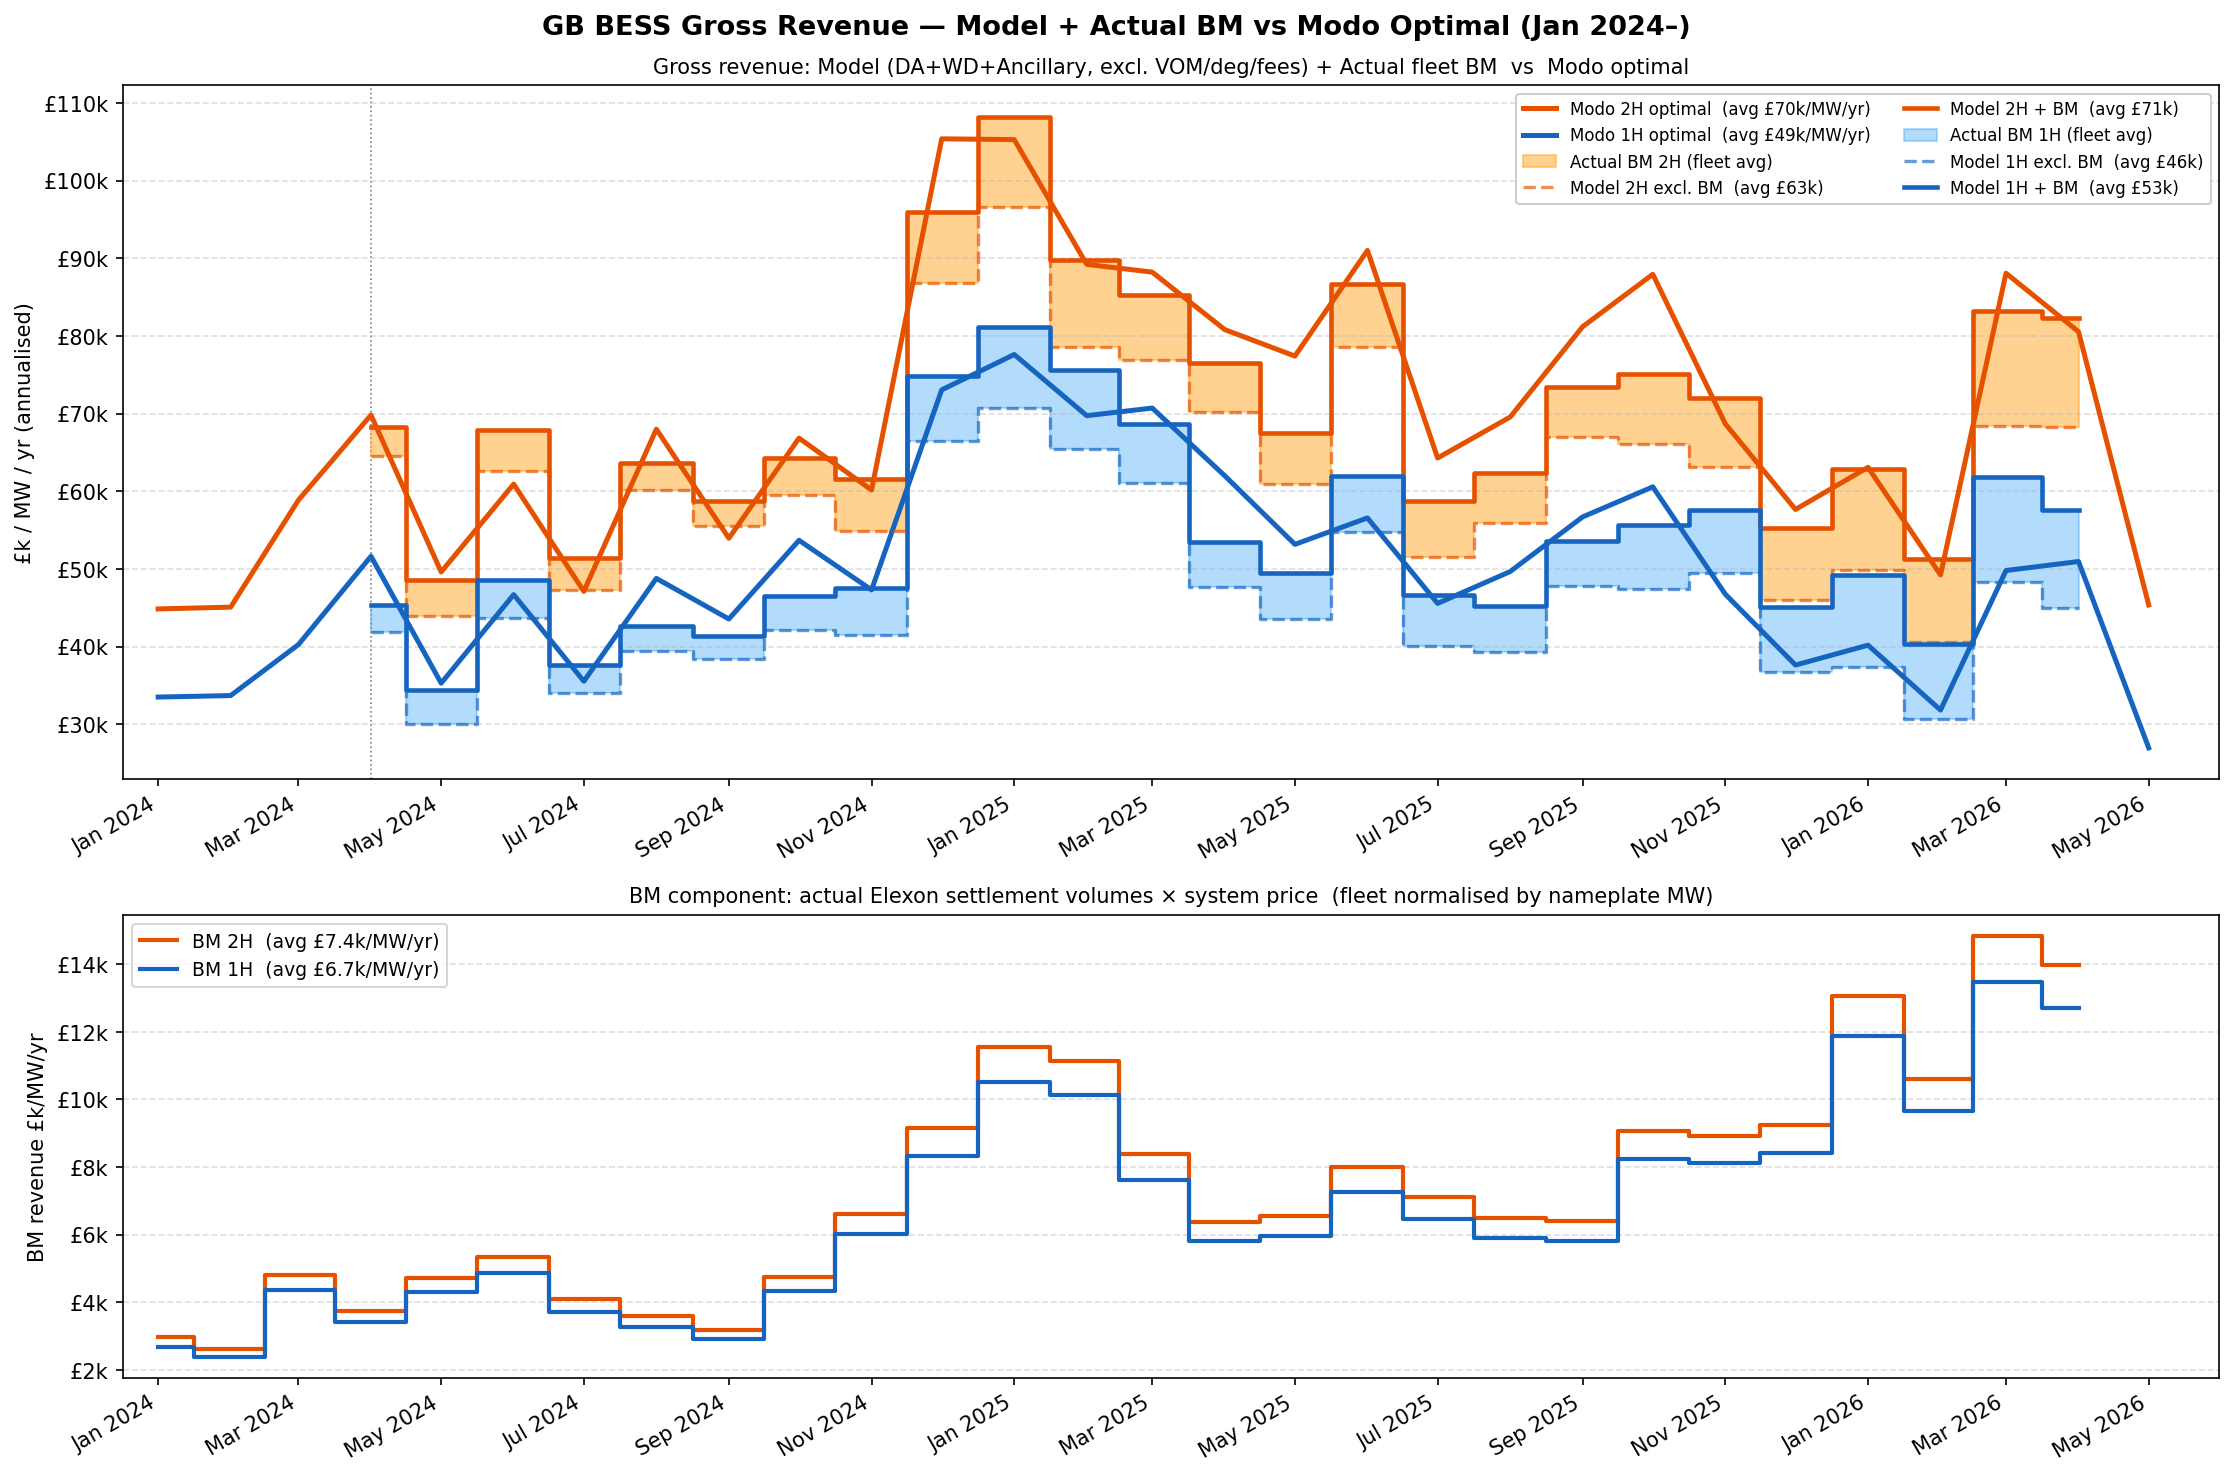

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates

PROCESSED  = PROJECT_ROOT / "data" / "processed"
PLOT_START = pd.Timestamp("2024-01-01")

m1 = pd.read_csv(PROCESSED / "historical_index_1h_monthly.csv")
m2 = pd.read_csv(PROCESSED / "historical_index_2h_monthly.csv")
for df in (m1, m2):
    df["period_dt"] = pd.to_datetime(df["year_month"])
m1["net_k"] = m1["total_net_gbp_mw_yr"] / 1000
m2["net_k"] = m2["total_net_gbp_mw_yr"] / 1000
model_start = m1["period_dt"].min()

bm1 = pd.read_csv(PROCESSED / "bm_index_1h.csv")
bm2 = pd.read_csv(PROCESSED / "bm_index_2h.csv")
for df in (bm1, bm2):
    df["period_dt"] = pd.to_datetime(df["year_month"])
    df["bm_k"] = df["bm_rev_gbp_mw_yr"] / 1000

def _load_modo(fname, col):
    df = pd.read_csv(PROJECT_ROOT / fname, parse_dates=["Date"])
    df = df.rename(columns={"Date": "date", col: "modo_k"})
    df["modo_k"] = pd.to_numeric(df["modo_k"], errors="coerce") / 1000
    return df.dropna(subset=["modo_k"]).sort_values("date").reset_index(drop=True)

modo1h = _load_modo("MODO 1H.csv", "ME BESS GB (1H)")
modo2h = _load_modo("MODO 2H.csv", "ME BESS GB (2H)")
modo1h_plot = modo1h[modo1h["date"] >= PLOT_START]
modo2h_plot = modo2h[modo2h["date"] >= PLOT_START]
x_end = max(modo1h_plot["date"].max(), modo2h_plot["date"].max()) + pd.Timedelta(days=30)

def stack(m, bm):
    s = m[["period_dt", "net_k"]].merge(bm[["period_dt", "bm_k"]], on="period_dt", how="left")
    s["stack_k"] = s["net_k"] + s["bm_k"].fillna(0)
    return s

s1 = stack(m1, bm1)
s2 = stack(m2, bm2)

BLUE, ORANGE = "#1565C0", "#E65100"

fig, axes = plt.subplots(2, 1, figsize=(15, 10), gridspec_kw={"height_ratios": [3, 2]})
fig.suptitle("GB BESS Gross Revenue — Model + Actual BM vs Modo Optimal (Jan 2024–)", fontsize=13, fontweight="bold")
ax1, ax2 = axes

ax1.plot(modo2h_plot["date"], modo2h_plot["modo_k"], color=ORANGE, linewidth=2.4, label=f"Modo 2H  (avg £{modo2h_plot['modo_k'].mean():.0f}k/MW/yr)")
ax1.plot(modo1h_plot["date"], modo1h_plot["modo_k"], color=BLUE,   linewidth=2.4, label=f"Modo 1H  (avg £{modo1h_plot['modo_k'].mean():.0f}k/MW/yr)")
ax1.fill_between(s2["period_dt"], s2["net_k"], s2["stack_k"], step="mid", alpha=0.50, color="#FFA726", label="Actual BM 2H")
ax1.step(s2["period_dt"], s2["net_k"],    where="mid", color=ORANGE, linewidth=1.6, linestyle="--", alpha=0.65, label=f"Model 2H excl BM  (£{m2['net_k'].mean():.0f}k)")
ax1.step(s2["period_dt"], s2["stack_k"], where="mid", color=ORANGE, linewidth=2.2, label=f"Model 2H+BM  (£{s2['stack_k'].mean():.0f}k)")
ax1.fill_between(s1["period_dt"], s1["net_k"], s1["stack_k"], step="mid", alpha=0.40, color="#42A5F5", label="Actual BM 1H")
ax1.step(s1["period_dt"], s1["net_k"],    where="mid", color=BLUE, linewidth=1.6, linestyle="--", alpha=0.65, label=f"Model 1H excl BM  (£{m1['net_k'].mean():.0f}k)")
ax1.step(s1["period_dt"], s1["stack_k"], where="mid", color=BLUE,   linewidth=2.2, label=f"Model 1H+BM  (£{s1['stack_k'].mean():.0f}k)")
ax1.axvline(model_start, color="grey", linewidth=0.8, linestyle=":", zorder=0)
ax1.set_ylabel("£k / MW / yr (annualised)")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"£{v:.0f}k"))
ax1.legend(fontsize=8, loc="upper right", framealpha=0.95, ncol=2)
ax1.grid(axis="y", linestyle="--", alpha=0.4)
ax1.set_title("Gross revenue: Model (DA+WD cap=60+Ancillary, excl. VOM/deg/fees) + Actual fleet BM  vs  Modo optimal", fontsize=10)
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax1.xaxis.set_major_locator(mdates.MonthLocator(bymonth=range(1,13,2)))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=30, ha="right")
ax1.set_xlim(PLOT_START - pd.Timedelta(days=15), x_end)

ax2.step(bm2["period_dt"], bm2["bm_k"], where="mid", color=ORANGE, linewidth=2.0, label=f"BM 2H  (avg £{bm2['bm_k'].mean():.1f}k/MW/yr)")
ax2.step(bm1["period_dt"], bm1["bm_k"], where="mid", color=BLUE,   linewidth=2.0, label=f"BM 1H  (avg £{bm1['bm_k'].mean():.1f}k/MW/yr)")
ax2.set_ylabel("BM £k/MW/yr")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"£{v:.0f}k"))
ax2.legend(fontsize=9)
ax2.grid(axis="y", linestyle="--", alpha=0.4)
ax2.set_title("BM component: Elexon settlement volumes x system price (fleet-normalised)", fontsize=10)
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax2.xaxis.set_major_locator(mdates.MonthLocator(bymonth=range(1,13,2)))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30, ha="right")
ax2.set_xlim(PLOT_START - pd.Timedelta(days=15), x_end)

plt.tight_layout()
plt.savefig(PROCESSED / "historical_index_with_bm.png", dpi=150, bbox_inches="tight")
plt.show()

ov = model_start
print(f"Modo 2H: £{modo2h_plot[modo2h_plot.date>=ov]['modo_k'].mean():.1f}k  Model+BM 2H: £{s2[s2.period_dt>=ov]['stack_k'].mean():.1f}k  Gap: £{modo2h_plot[modo2h_plot.date>=ov]['modo_k'].mean()-s2[s2.period_dt>=ov]['stack_k'].mean():.1f}k")
print(f"Modo 1H: £{modo1h_plot[modo1h_plot.date>=ov]['modo_k'].mean():.1f}k  Model+BM 1H: £{s1[s1.period_dt>=ov]['stack_k'].mean():.1f}k  Gap: £{modo1h_plot[modo1h_plot.date>=ov]['modo_k'].mean()-s1[s1.period_dt>=ov]['stack_k'].mean():.1f}k")